In [1]:
#easter egg :p
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
spy = yf.download("SPY", start="1993-01-01")


prices = spy["Close"]
daily_returns = prices.pct_change()


#cumprod returns cumulative_product
#always vectorize

cumulative_returns = (1 + daily_returns).cumprod() - 1
    #  (100% + x).cumprod()


#spy.head()
daily_returns.head()
cumulative_returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
1993-01-29,NaN
1993-02-01,0.007113
1993-02-02,0.009247
1993-02-03,0.019915
1993-02-04,0.024182


In [3]:
rolling_peak = prices.cummax()
drawdown = prices / rolling_peak - 1
drawdown.head()
print(drawdown.min())

equity_curve = (1 + daily_returns).cumprod() 

Ticker
SPY   -0.551894
dtype: float64


<Figure size 1200x600 with 0 Axes>

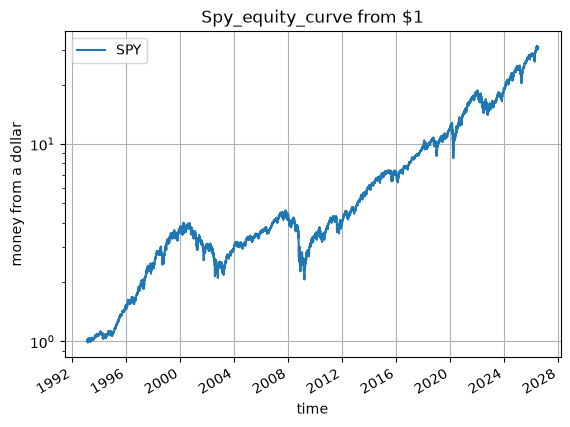

In [4]:
plt.figure(figsize = (12,6))
equity_curve.plot(label = "spy equity curve")
plt.title("Spy_equity_curve from $1")
plt.xlabel("time")
plt.ylabel("money from a dollar")
plt.grid(True)
plt.yscale("log")
plt.legend()

<Axes: xlabel='Date'>

<Figure size 640x480 with 0 Axes>

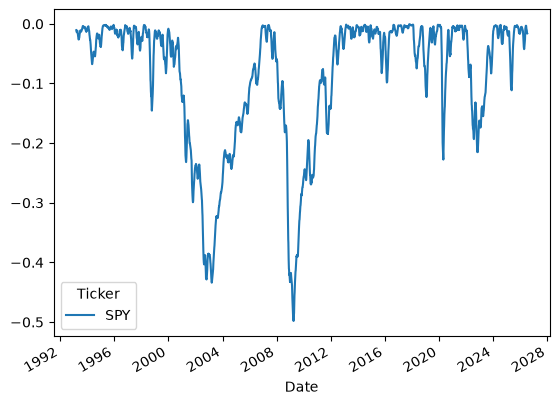

In [5]:
# plt.figure()
# drawdown.plot(label = "drawdown")
# plt.title("Drawdown Plot")
# plt.xlabel("time")
# plt.ylabel("curr drop from max")
# plt.grid(True)
# plt.legend()

#interesting plot: to make smooth, using rolling(window = x)


smoothed_drawdown = drawdown.rolling(window=30).mean()

plt.figure()
smoothed_drawdown.plot(label = "smoothed_darwodnw0")

In [6]:
total_return = equity_curve.iloc[-1]

years = len(daily_returns.dropna()) / 252

cagr = total_return ** (1 / years) - 1


#standard deviation of yearly returns
annualized_volatility = np.sqrt(252) * daily_returns.std()

sharpe_ratio = daily_returns.mean() / daily_returns.std() * np.sqrt(252)

max_drawdown = drawdown.min()

In [7]:
summary_stats = pd.Series({
    "CAGR": cagr,
    "Annualized Volatility": annualized_volatility,
    "Sharpe Ratio": sharpe_ratio,
    "Max Drawdown": max_drawdown
})

summary_stats

CAGR                     Ticker
SPY    0.108229
Name: 2026-07-02 00:00:...
Annualized Volatility                Ticker
SPY    0.185732
dtype: float64
Sharpe Ratio                         Ticker
SPY    0.646308
dtype: float64
Max Drawdown                         Ticker
SPY   -0.551894
dtype: float64
dtype: object

In [8]:
depth = -0.05
length = 21 #if it goes down 5% in the last 21 days, we buy
hold = 21 #and then we hold it for 21 days

In [9]:
#there is only invested and not invested.

In [10]:
rolling_peak = prices.rolling(21).max()
rolling_drawdown = prices / rolling_peak - 1
buy_signal = rolling_drawdown <= depth #boolean list

position = buy_signal.rolling(hold).max() #1 if buy_signal is 1 in the past 'hold' days
position = position.fillna(0) #else 0

position = position.shift(1).fillna(0) #no cheating
strategy_returns = position * daily_returns
btd_equity_curve = (1 + strategy_returns).cumprod()

Text(0, 0.5, 'money change')

<Figure size 640x480 with 0 Axes>

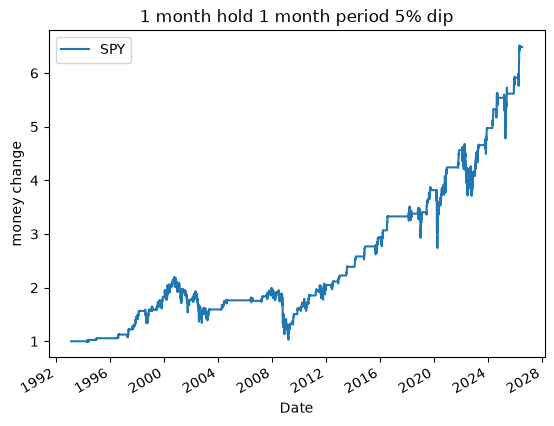

In [11]:
plt.figure()
btd_equity_curve.plot(label="SPY")
plt.title("1 month hold 1 month period 5% dip")
plt.legend()
plt.ylabel("money change")

In [12]:
#note how it's pretty bad here. that's what we expected

equity_curve = equity_curve.squeeze()
btd_equity_curve = btd_equity_curve.squeeze()

In [13]:
#comparing the two:
comparison = pd.DataFrame({
    "Buy and hold" : equity_curve,
    "BTD, 5%, month, month" : btd_equity_curve
})

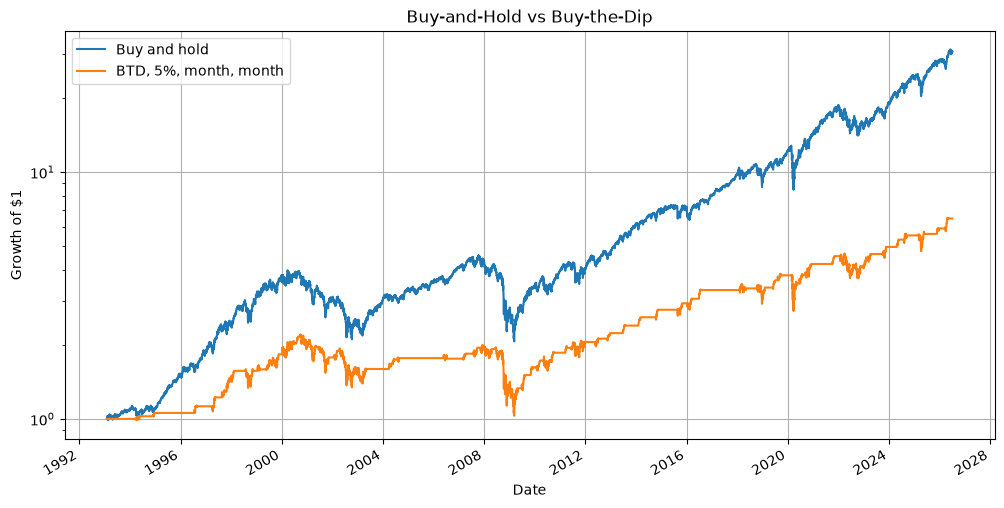

In [14]:
comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [15]:
btd_equity_curve = btd_equity_curve.squeeze()
equity_curve = equity_curve.squeeze()
daily_returns = daily_returns.squeeze()
strategy_returns = strategy_returns.squeeze()
drawdown = drawdown.squeeze()

years = len(daily_returns.dropna()) / 252

buy_hold_total_return = equity_curve.iloc[-1]
buy_hold_cagr = buy_hold_total_return ** (1 / years) - 1
buy_hold_vol = daily_returns.std() * np.sqrt(252)
buy_hold_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
buy_hold_max_drawdown = drawdown.min()



In [16]:
btd_total_return = btd_equity_curve.iloc[-1]
btd_cagr = btd_total_return ** (1 / years) - 1
btd_vol = strategy_returns.std() * np.sqrt(252)
btd_sharpe = strategy_returns.mean() / strategy_returns.std() * np.sqrt(252)

btd_drawdown = btd_equity_curve / btd_equity_curve.cummax() - 1
btd_max_drawdown = btd_drawdown.min()


In [17]:
summary_table = pd.DataFrame({
    "Buy and Hold": [
        buy_hold_cagr,
        buy_hold_vol,
        buy_hold_sharpe,
        buy_hold_max_drawdown
    ],
    "BTD -5%, 1M lookback, 1M hold": [
        btd_cagr,
        btd_vol,
        btd_sharpe,
        btd_max_drawdown
    ]
}, index=[
    "CAGR",
    "Annualized Volatility",
    "Sharpe Ratio",
    "Max Drawdown"
])

summary_table

,Buy and Hold,"BTD -5%, 1M lookback, 1M hold"
CAGR,0.108229,0.057603
Annualized Volatility,0.185732,0.155473
Sharpe Ratio,0.646308,0.437918
Max Drawdown,-0.551894,-0.531486


In [18]:
def run_btd_strategy(prices, daily_returns, depth, lookback=21, hold=21):
    prices = prices.squeeze()
    daily_returns = daily_returns.squeeze() #squeeze from df to series

    rolling_peak = prices.rolling(lookback).max()
    rolling_drawdown = prices / rolling_peak - 1

    buy_signal = rolling_drawdown <= depth

    position = buy_signal.rolling(hold).max()
    position = position.fillna(0)
    position = position.shift(1).fillna(0)


    strategy_returns = position * daily_returns
    strategy_returns = strategy_returns.fillna(0)

    equity_curve = (1 + strategy_returns).cumprod()

    return strategy_returns, equity_curve

    

In [19]:
btd_5_returns, btd_5_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.05,
    lookback=21,
    hold=21
)

btd_10_returns, btd_10_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.10,
    lookback=21,
    hold=21
)

btd_20_returns, btd_20_equity = run_btd_strategy(
    prices,
    daily_returns,
    depth=-0.20,
    lookback=21,
    hold=21
)

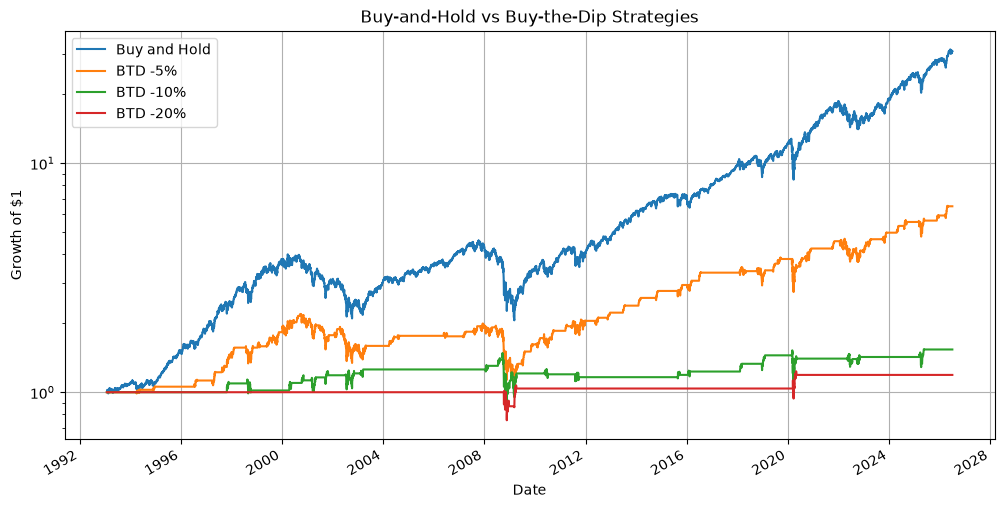

In [20]:
equity_comparison = pd.DataFrame({
    "Buy and Hold": equity_curve.squeeze(),
    "BTD -5%": btd_5_equity.squeeze(),
    "BTD -10%": btd_10_equity.squeeze(),
    "BTD -20%": btd_20_equity.squeeze()
})

equity_comparison.plot(figsize=(12, 6), logy=True)
plt.title("Buy-and-Hold vs Buy-the-Dip Strategies")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [21]:
def compute_stats(returns, equity_curve):
    returns = returns.squeeze().fillna(0)
    equity_curve = equity_curve.squeeze()

    years = len(returns) / 252

    cagr = equity_curve.iloc[-1] ** (1 / years) - 1
    vol = returns.std() * np.sqrt(252)

    if returns.std() == 0:
        sharpe = np.nan
    else:
        sharpe = returns.mean() / returns.std() * np.sqrt(252)

    drawdown = equity_curve / equity_curve.cummax() - 1
    max_drawdown = drawdown.min()

    return pd.Series({
        "CAGR": cagr,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown
    })

In [22]:
depths = [-0.05, -0.10, -0.15, -0.20]

lookbacks = {
    "1W": 5,
    "2W": 10,
    "3W": 15,
    "1M": 21,
    "3M": 63,
    "6M": 126,
    "1Y": 252
}

holds = {
    "1M": 21,
    "2M": 42,
    "3M": 63,
    "6M": 126,
    "1Y": 252,
    "3Y": 756,
    "5Y": 1260
}

all_returns = {}
all_equity = {}
rows = []

for depth in depths:
    for lookback_name in lookbacks:
        for hold_name in holds:
            lookback = lookbacks[lookback_name]
            hold = holds[hold_name]

            name = f"{int(abs(depth) * 100)}% depth, {lookback_name} lookback, {hold_name} hold"

            rets, eq = run_btd_strategy(
                prices,
                daily_returns,
                depth=depth,
                lookback=lookback,
                hold=hold
            )

            all_returns[name] = rets
            all_equity[name] = eq

            stats = compute_stats(rets, eq)
            stats["Depth"] = depth
            stats["Lookback"] = lookback_name
            stats["Hold"] = hold_name
            stats["Strategy"] = name

            rows.append(stats)

results = pd.DataFrame(rows)
returns_df = pd.DataFrame(all_returns)
equity_df = pd.DataFrame(all_equity)

In [23]:
len(results)

196

In [24]:
results["Sharpe Ratio"].isna().sum()

np.int64(7)

In [25]:
stats

CAGR                                            0.064484
Annualized Volatility                           0.153186
Sharpe Ratio                                    0.484481
Max Drawdown                                   -0.496864
Depth                                               -0.2
Lookback                                              1Y
Hold                                                  5Y
Strategy                 20% depth, 1Y lookback, 5Y hold
dtype: object

In [26]:
rows

[CAGR                                           0.029433
 Annualized Volatility                          0.132094
 Sharpe Ratio                                   0.285519
 Max Drawdown                                   -0.40532
 Depth                                             -0.05
 Lookback                                             1W
 Hold                                                 1M
 Strategy                 5% depth, 1W lookback, 1M hold
 dtype: object,
 CAGR                                           0.043488
 Annualized Volatility                          0.142368
 Sharpe Ratio                                    0.37006
 Max Drawdown                                  -0.446802
 Depth                                             -0.05
 Lookback                                             1W
 Hold                                                 2M
 Strategy                 5% depth, 1W lookback, 2M hold
 dtype: object,
 CAGR                                           0.045744

In [27]:
best_idx = results["CAGR"].idxmax()
best_strategy = results.loc[best_idx, "Strategy"]

best_strategy

'5% depth, 3M lookback, 6M hold'

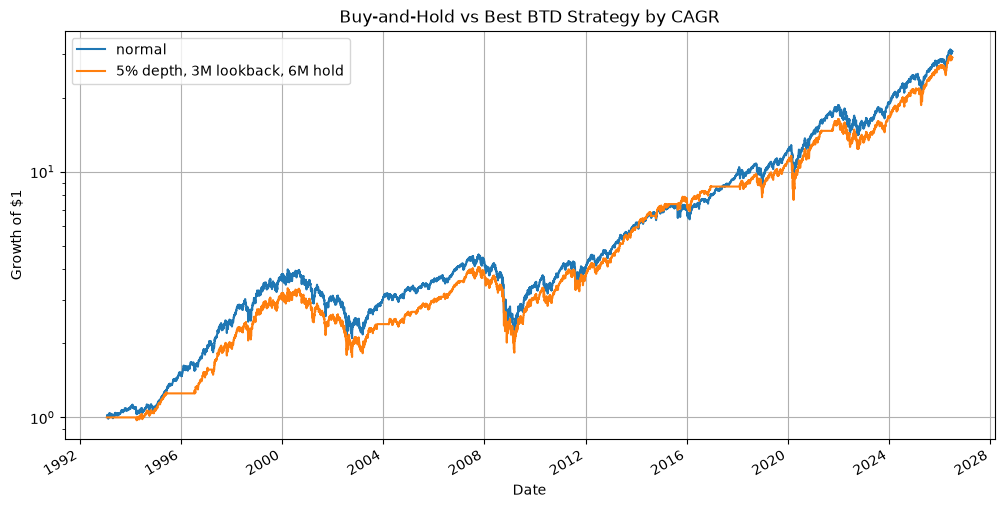

In [28]:
comparison = pd.DataFrame ({
    "normal" : equity_curve.squeeze(),
    best_strategy: equity_df[best_strategy].squeeze()
})

comparison.plot(figsize=(12, 6), logy=True)

plt.title("Buy-and-Hold vs Best BTD Strategy by CAGR")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True)
plt.show()

In [29]:
buy_hold_stats = compute_stats(daily_returns, equity_curve)
best_btd_stats = results.loc[best_idx]

pd.DataFrame({
    "Buy and Hold": buy_hold_stats,
    "Best BTD by CAGR": best_btd_stats[["CAGR", "Annualized Volatility", "Sharpe Ratio", "Max Drawdown"]]
})

,Buy and Hold,Best BTD by CAGR
CAGR,0.108215,0.106295
Annualized Volatility,0.185721,0.180009
Sharpe Ratio,0.646270,0.651311
Max Drawdown,-0.551894,-0.551894


In [30]:
#next section completed: analysis of t-scores, significance tests
#expect partially different results due to different sources of data

In [31]:
best_strategy

'5% depth, 3M lookback, 6M hold'

In [32]:
y = returns_df[best_strategy].squeeze()
x = daily_returns.squeeze()

data = pd.DataFrame({
    "BTD": y,
    "SPY": x
}).dropna()

#beta = cov(x,y) / var(x)
beta = data["BTD"].cov(data["SPY"]) / data["SPY"].var()

In [33]:
beta

np.float64(0.9394020602929716)

In [34]:
daily_alpha = data["BTD"].mean() - beta * data["SPY"].mean()

In [35]:
alpha = 252 * daily_alpha

In [36]:
alpha

np.float64(0.004490050108672265)

In [37]:
regression_rows = []

for strategy in returns_df.columns:
    y = returns_df[strategy].squeeze()
    x = daily_returns.squeeze()

    data = pd.DataFrame({
        "Strategy": y,
        "SPY": x
    }).dropna()

    beta = data["Strategy"].cov(data["SPY"]) / data["SPY"].var()
    daily_alpha = data["Strategy"].mean() - beta * data["SPY"].mean()
    annual_alpha = 252 * daily_alpha
    correlation = data["Strategy"].corr(data["SPY"])
    r_squared = correlation ** 2

    regression_rows.append({
        "Strategy": strategy,
        "Beta": beta,
        "Annual Alpha": annual_alpha,
        "Correlation": correlation,
        "R Squared": r_squared
    })

regression_results = pd.DataFrame(regression_rows)

regression_results.head()

/Users/calebgoodman/Documents/coding/aqr-hold-the-dip/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/calebgoodman/Documents/coding/aqr-hold-the-dip/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/calebgoodman/Documents/coding/aqr-hold-the-dip/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/calebgoodman/Documents/coding/aqr-hold-the-dip/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/calebgoodman/Documents/coding/aqr-hold-the-dip/venv/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3036: RuntimeWarning: invalid value encountered in divide
  c /= stddev

,Strategy,Beta,Annual Alpha,Correlation,R Squared
0,"5% depth, 1W lookback, 1M hold",0.505524,-0.022963,0.710751,0.505167
1,"5% depth, 1W lookback, 2M hold",0.587224,-0.017799,0.766039,0.586816
2,"5% depth, 1W lookback, 3M hold",0.645534,-0.021629,0.803195,0.645122
3,"5% depth, 1W lookback, 6M hold",0.753518,-0.017453,0.867826,0.753123
4,"5% depth, 1W lookback, 1Y hold",0.860840,-0.032706,0.927598,0.860439


In [38]:
full_results = results.merge(regression_results, on="Strategy")

full_results.sort_values("Annual Alpha", ascending=False).head(10)

,CAGR,Annualized Volatility,Sharpe Ratio,Max Drawdown,Depth,Lookback,Hold,Strategy,Beta,Annual Alpha,Correlation,R Squared
181,0.074863,0.144113,0.572902,-0.356426,-0.20,3M,5Y,"20% depth, 3M lookback, 5Y hold",0.601769,0.010336,0.775508,0.601413
111,0.056848,0.127990,0.495923,-0.322517,-0.15,2W,5Y,"15% depth, 2W lookback, 5Y hold",0.474516,0.006520,0.688552,0.474104
160,0.050563,0.121115,0.467700,-0.322517,-0.20,2W,5Y,"20% depth, 2W lookback, 5Y hold",0.424869,0.005651,0.651503,0.424456
104,0.050380,0.121057,0.466430,-0.322517,-0.15,1W,5Y,"15% depth, 1W lookback, 5Y hold",0.424458,0.005519,0.651187,0.424045
31,0.106295,0.180009,0.651311,-0.551894,-0.05,3M,6M,"5% depth, 3M lookback, 6M hold",0.939402,0.004490,0.969208,0.939365
167,0.049380,0.121906,0.456243,-0.322517,-0.20,3W,5Y,"20% depth, 3W lookback, 5Y hold",0.430441,0.003955,0.655766,0.430029
118,0.073038,0.149806,0.545525,-0.386433,-0.15,3W,5Y,"15% depth, 3W lookback, 5Y hold",0.650271,0.003674,0.806171,0.649911
55,0.095528,0.172118,0.616187,-0.475159,-0.10,1W,5Y,"10% depth, 1W lookback, 5Y hold",0.858710,0.002990,0.926574,0.858539
24,0.102528,0.178598,0.635928,-0.564173,-0.05,1M,6M,"5% depth, 1M lookback, 6M hold",0.924681,0.002590,0.961560,0.924597
45,0.103759,0.180403,0.637555,-0.551894,-0.05,1Y,6M,"5% depth, 1Y lookback, 6M hold",0.943490,0.001774,0.971300,0.943424


## Discrepencies in Results Between this Notebook & AQR's Results

Many instances in my methodology may have resulted in different data prior to analysis; let's explore these potential factors.

1) The data used was different. I used spy from 1990 onwards, while they used a wealth of additional data, meaning that their results likely had additional merit.

2) I was unsure how they calculated rolling drawdown, so I implemented a sliding window approach. I thought that this was a good idea, because a long, slow decline isn't the same as a 'dip' in my opinion. AQR may have done something different, or may have a completely different interpretation.

3) Slight methodology differences may also make a difference. I mentioned my rolling window approach, but other ideas like assuming cash return (while money is uninvested, which I did NOT do) can result in large differences.

Overall, these differences provide several plausible explanations for why my results differ from AQR's. In particular, the shorter SPY sample, simplified implementation assumptions, and alternative dip definition all affect strategy behavior. Additionally, AQR evaluates buy-the-dip strategies over a broader market history and across many market environments, whereas this notebook focuses exclusively on SPY. Consequently, this project should be viewed as a faithful conceptual replication rather than an exact numerical reproduction.

Despite these differences, the primary objective of this project was not to reproduce AQR's exact numerical results, but to replicate the underlying methodology and evaluate whether similar conclusions emerge under a simplified SPY-based implementation.

I will **not** be buying (nor holding) the dip, no matter what polymarket chatters seem to believe. 